<a href="https://colab.research.google.com/github/EulojioEstudillo7/Luna-dataset-Project/blob/main/Eulojio_Estudillo_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1
# Malignant Lung Nodule Detection

In this project, you will develop a deep learning model to classify lung nodules as benign or malignant from 3D CT scans, utilizing the LUNA16 dataset. This task involves data preprocessing, model design, training, and evaluation, offering hands-on experience with medical image analysis and deep learning in PyTorch.

## 1. Load Annotation Data
As the first step, we will need to load the processed annotation data created in class. Please review the "DataPreparation" notebook for details.

1.1 Upload the annotation CSV file to the current Colab environment.

In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

1.2 Load the `candidates_processed.csv` file as a data frame. Display the first 5 rows.

In [2]:
data = pd.read_csv('candidates_processed.csv')
data.head()

,seriesuid,class,index,row,col
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,110,331,173
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,24,287,86
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,34,343,371
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,27,295,437
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,0,51,311,146


1.3 Display the number of class 0 (benign) records and the number of class 1 (malignant) records. Your results should indicate that the two classes are highly imbalanced.

In [3]:
data['class'].value_counts()

,count
class,
0,78997
1,138


## 2. Find Nodule Locations
In the annotation dataset, the center of each identified lung nodule is marked with its 3D coordinates. We need to convert these coordinates into three indices to identify the specific subarray in each CT scan tensor that corresponds to the nodule.

Please follow the steps outlined in the LUNA16DataPreparation notebook to generate a CSV file named `candidates_processed.csv`, which will store the indices for the center of each lung nodule.

2.1 Load the `subset0.zip` from Google Drive using the file ID '1OFa8UhDvCrcTj1VkFLa7RjifEqMD4TAa'. Extract the zip file to reveal the .mhd and .raw files.

In [4]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

id='1OFa8UhDvCrcTj1VkFLa7RjifEqMD4TAa'
downloaded = drive.CreateFile({'id': id})
downloaded.GetContentFile('subset0.zip')

In [5]:
! unzip -q subset0.zip


In [6]:
! pip install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 12.8 MB/s eta 0:00:00


2.2 Use `matplotlib` library to visualize the first malignant lung nodule in the dataset. Create an image to display a 2D slice from each of its three dimensions.

In [7]:
data[data['class'] == 1].iloc[0]

,1512
seriesuid,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...
class,1
index,33
row,348
col,110


In [8]:
import SimpleITK as sitk

series_uid = data.loc[data['class'] == 1 , 'seriesuid'].iloc[0]
print(series_uid)


1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492


In [9]:
mhd_path = 'subset0/{}.mhd'.format(series_uid)
mhd_path

'subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd'

In [10]:
ct_mhd = sitk.ReadImage(mhd_path)

ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
ct_a.clip(-1000, 1000, ct_a)
clim = (-1000, 300)

0.7421879768371582 0.7421879768371582 2.5


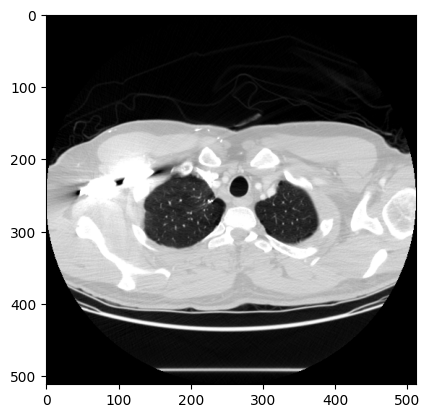

In [11]:
spacingX, spacingY, spacingZ = ct_mhd.GetSpacing()
print(spacingX, spacingY, spacingZ)
plt.imshow(ct_a[100, :, :], clim=clim, cmap='gray', aspect=spacingX/spacingY)

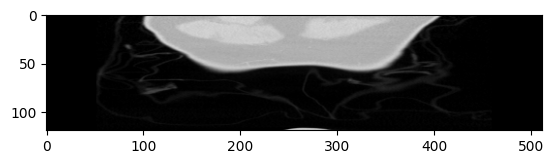

In [12]:
plt.imshow(ct_a[:, 100, :], clim=clim, cmap='gray', aspect=spacingX/spacingY)

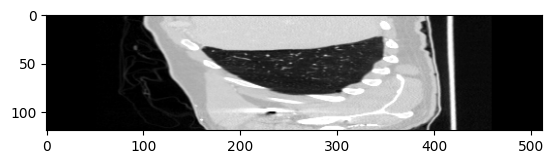

In [13]:
plt.imshow(ct_a[:, :, 100], clim=clim, cmap='gray', aspect=spacingX/spacingY)

## 3. Create Data Tensors

The neural network model we will build with PyTorch requires the data to be presented in the form of a torch tensor. The input tensor should be 4-dimensional, with the dimensions representing the nodule index, channel, row, and column, respectively.

3.1 Write a double for-loop to extract the CT scan data for **the first 5,000*** nodules:
- The outer for loop goes through all the distince seriesuid's.
- For each iteration of the outer loop, load the corresponding CT-scan file and create a torch tensor to represent the scan.
- Create an inner-loop that goes through the nodules corresponding to the seriesuid:
    - Load the (index, row, col) tuple of this nodule from the data frame.
    - Extract a 32x48x48 chunk centered at the (index, row, col). If the nodule is near the edge of the image and there is not enough indices to extract, please pad with zeros to keep the overall shape unchanged.
    - Use a 4D tensor to contain all the 32x48x48 chunks. The first dimension of the 4D tensor is the index of nodule.

You may modify the above procedure as you like. Make sure that you are able to obtain a 4D tensor that contains all nodule data. **Display the shape of the 4D tensor.** The shape of the tensor should be (5000, 32, 48, 48).

**Remark** Due to the memory limit, it is impossible to load all nodule images into simultanously. Therefore, the number of nodules required in this section is reduced to 5,000. Feel free to adjust this number to prevent the out-of-memory error.

In [14]:
import torch
import numpy as np
import SimpleITK as sitk

chunks = []

for series_uid in data['seriesuid'].unique():
  if len(chunks) >= 5000:
        break

  mhd_path = 'subset0/{}.mhd'.format(series_uid)
  ct_mhd = sitk.ReadImage(mhd_path)
  ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
  ct_a.clip(-1000, 1000, ct_a)
  ct_a = np.pad(ct_a,((16,16), (24,24), (24,24)), mode='constant', constant_values=0)
  t = torch.from_numpy(ct_a)
  nodules = data[data['seriesuid'] == series_uid][['index', 'row', 'col']].values
  for index, row, col in nodules:
    if len(chunks) >= 5000:
            break
    index_p = int(index) + 16
    row_p   = int(row) + 24
    col_p   = int(col) + 24
    ct_chunk = t[(index_p-16):(index_p+16), (row_p-24):(row_p+24), (col_p-24):(col_p+24)]
    if ct_chunk.shape == (32, 48, 48):
        chunks.append(ct_chunk)

nodule_tensor = torch.stack(chunks)

print(nodule_tensor.shape)

torch.Size([5000, 32, 48, 48])


3.2 Create a 1D tensor to contain all the class information.

In [15]:
t_class = torch.tensor(data['class'].values)
t_class.shape


torch.Size([79135])

3.3 Split the 4D tensor into a training set and a test set. Display their shapes.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(nodule_tensor, t_class[:len(nodule_tensor)], test_size=0.2, random_state=42, shuffle=True)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: torch.Size([4000, 32, 48, 48])
X_test shape: torch.Size([1000, 32, 48, 48])
y_train shape: torch.Size([4000])
y_test shape: torch.Size([1000])


## 4. Model Design and Implementation

4.1 Design a neural network model with only a flatten layer and two dense layers for classifying lung nodules. You may experiment with different sizes for the hidden layers to improve the training results.

In [17]:
import torch.nn as nn
import torch.optim as optim

class NeuralNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.dense1 = nn.Linear(32 * 48 * 48, 512)
    self.relu1 = nn.ReLU()
    self.dense2 = nn.Linear(512, 64)
    self.relu2 = nn.ReLU()
    self.dense3 = nn.Linear(64, 1)


  def forward(self, x):
    x = self.flatten(x)
    x = self.dense1(x)
    x = self.relu1(x)
    x = self.dense2(x)
    x = self.relu2(x)
    x = self.dense3(x)

    return x

In [18]:
model = NeuralNet()

4.2 Create an object to represent the loss function.

In [19]:
criterion = nn.BCEWithLogitsLoss()
def BcrossEntropy_loss(y_pred, y_true):
    return criterion(y_pred, y_true)

In [20]:
loss_func = BcrossEntropy_loss

4.3 Create an object to represent the optimizer.

In [21]:
def optimizer(model):
  opt = optim.Adam(model.parameters(), lr=0.001)
  return opt

In [22]:
opt = optimizer(model)

In [23]:
y_train = y_train.float().unsqueeze(1)

4.4 Create a function to represent the training loop.


In [24]:
from torch.utils.data import TensorDataset, DataLoader

def train_model(model, loss_func, opt, x_train, y_train, n_epochs, batch_size=32):
    train_dataset = TensorDataset(x_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(n_epochs):
        total_loss = 0
        for batch_x, batch_y in train_loader:
            predictions = model(batch_x).view(batch_x.size(0), 1)
            loss = loss_func(predictions, batch_y)

            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"Epoch: {epoch+1}, Avg Loss: {avg_loss:.4f}")

4.5 Execute the training loop. Display the change of training loss during the training process. Choose a reasonable value for the number of training epochs based on your observations.

In [25]:
model = NeuralNet()
opt = optimizer(model)
loss_func = BcrossEntropy_loss

train_model(model, loss_func, opt, X_train, y_train, 30)

Epoch: 1, Avg Loss: 108.6379
Epoch: 2, Avg Loss: 0.4181
Epoch: 4, Avg Loss: 2.1556
Epoch: 6, Avg Loss: 1.6297
Epoch: 8, Avg Loss: 0.3727
Epoch: 10, Avg Loss: 0.8117
Epoch: 12, Avg Loss: 0.0005
Epoch: 14, Avg Loss: 0.0005
Epoch: 16, Avg Loss: 0.0005
Epoch: 18, Avg Loss: 0.0005
Epoch: 20, Avg Loss: 0.0005
Epoch: 22, Avg Loss: 0.0005
Epoch: 24, Avg Loss: 0.0005
Epoch: 26, Avg Loss: 0.0005
Epoch: 28, Avg Loss: 0.0005
Epoch: 30, Avg Loss: 0.0005


## 5. Model Evaluation and Analysis

5.1 Obtain the model's prediction on the test set.

In [26]:
model.eval()

with torch.no_grad():
    raw_logits = model(X_test)
    predictions = (torch.sigmoid(raw_logits) >= 0.5).float()

print(predictions)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
      

5.2 Calculate the report the following metrics:
- accuracy
- precision
- recall

5.3: Discuss the model's performance.

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
y_true = y_test.numpy()
y_pred = predictions.numpy()

print("Accuracy:",  accuracy_score(y_true, y_pred))
print("Precision:",  precision_score(y_true, y_pred, zero_division=0))
print("Recall:",   recall_score(y_true, y_pred, zero_division=0))

Accuracy: 0.998
Precision: 0.0
Recall: 0.0


## 6. Data Augmentation and Retraining

To enhance the model's performance, it is essential to increase the number of malignant instances. Apply random shifting and rotation to generate new training instances, ensuring an equal number of instances in each class within the training set.

6.1 Augment the number of malignent instances in the training set.

In [28]:
y_true_5000 = t_class[:len(nodule_tensor)].numpy()

print(y_true_5000[y_true_5000 == 0].shape[0])
print(y_true_5000[y_true_5000 == 1].shape[0])
print(y_true_5000.shape[0])


4996
4
5000


In [29]:
print(model)

NeuralNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense1): Linear(in_features=73728, out_features=512, bias=True)
  (relu1): ReLU()
  (dense2): Linear(in_features=512, out_features=64, bias=True)
  (relu2): ReLU()
  (dense3): Linear(in_features=64, out_features=1, bias=True)
)


In [30]:
data_positive = data[data['class'] == 1]
print("Total number of positive instances:", len(data_positive))
data_positive.head(10)

Total number of positive instances: 138


,seriesuid,class,index,row,col
1512,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...,1,33,348,110
2225,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,1,56,338,409
2400,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,1,68,286,425
3109,1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674...,1,187,351,427
5070,1.3.6.1.4.1.14519.5.2.1.6279.6001.124154461048...,1,41,229,458
7093,1.3.6.1.4.1.14519.5.2.1.6279.6001.126264578931...,1,523,265,366
8101,1.3.6.1.4.1.14519.5.2.1.6279.6001.128023902651...,1,101,381,324
9236,1.3.6.1.4.1.14519.5.2.1.6279.6001.129055977637...,1,370,354,118
9570,1.3.6.1.4.1.14519.5.2.1.6279.6001.130438550890...,1,222,270,390
10830,1.3.6.1.4.1.14519.5.2.1.6279.6001.134996872583...,1,164,276,177


In [31]:
nodule_index = data_positive.index[0]
uid = data_positive.loc[nodule_index, 'seriesuid']

mhd_path = "subset0/" + uid + ".mhd"
ct_mhd = sitk.ReadImage(mhd_path)
ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
ct_a = ct_a.clip(-1000, 1000, ct_a)

index, row, col = data.loc[nodule_index, ["index", "row", "col"]]
ct_chunk = torch.zeros([32, 48, 48])
chunk = ct_a[(index-16):(index+16), (row-24):(row+24), (col-24):(col+24)]
chunk_indices, chunk_rows, chunk_cols = chunk.shape
ct_chunk[:chunk_indices, :chunk_rows, :chunk_cols] = torch.tensor(chunk)
label = data.loc[nodule_index, 'class']

ct_chunk.shape, label

(torch.Size([32, 48, 48]), np.int64(1))

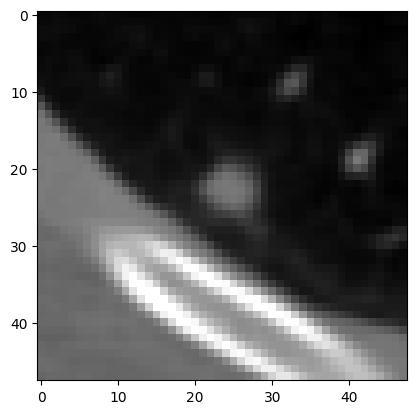

In [32]:
import matplotlib.pyplot as plt
plt.imshow(ct_chunk[16, :, :], cmap='gray')
plt.show()

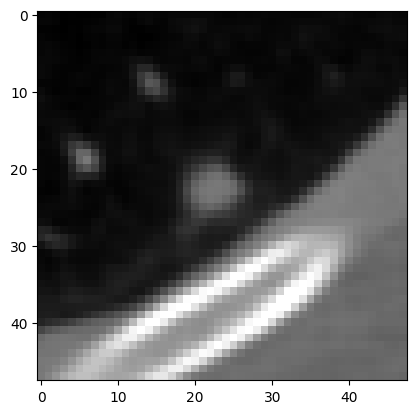

In [33]:
flip_chunk = torch.flip(ct_chunk, [2])
plt.imshow(flip_chunk[16, :, :], cmap='gray')
plt.show()

torch.Size([32, 48, 48])


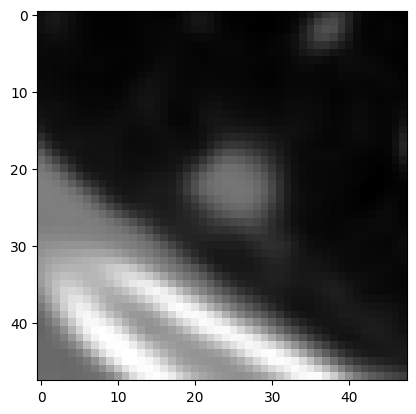

In [34]:
from torchvision.transforms import Resize, CenterCrop
scale = 1.5
new_size = int(48 * scale)

resize_fn = Resize(new_size)
scaled_chunk = resize_fn(ct_chunk)

crop_fn = CenterCrop(size=(48, 48))
temp = crop_fn(scaled_chunk)

print(temp.shape)
plt.imshow(temp[16, :, :], cmap='gray')
plt.show()

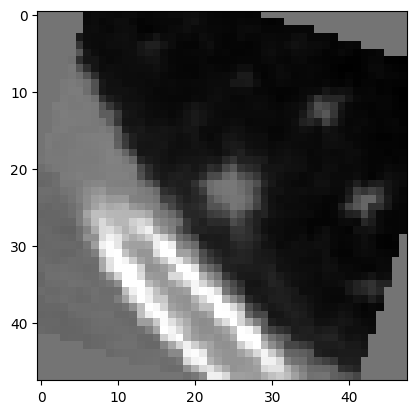

In [35]:
from torchvision.transforms import RandomRotation
rotate_fn = RandomRotation(45)
rotated_chunk = rotate_fn(ct_chunk)
plt.imshow(rotated_chunk[16, :, :], cmap='gray')
plt.show()

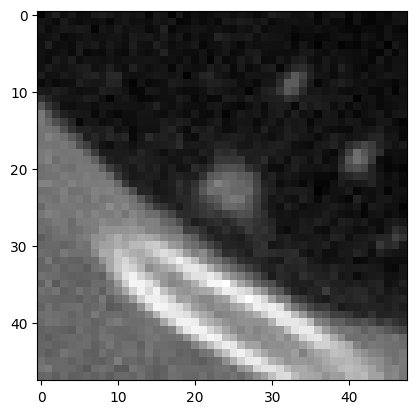

In [36]:
from torchvision.transforms.v2 import GaussianNoise
noise_fn = GaussianNoise(sigma=50, clip=False)
new_chunk = noise_fn(ct_chunk[[16], :, :])
plt.imshow(new_chunk[0, :, :], cmap='gray')
plt.show()

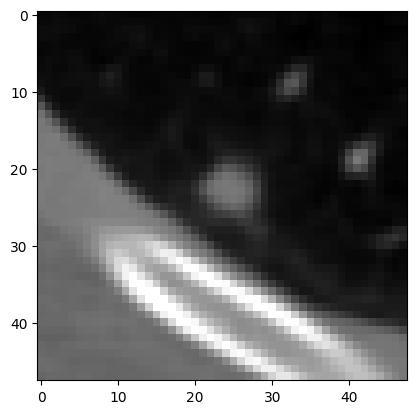

In [37]:
plt.imshow(ct_chunk[16, :, :], cmap='gray')

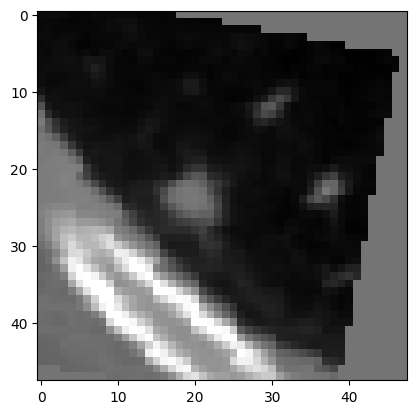

In [38]:
from torchvision.transforms.v2 import RandomAffine
shift_fn = RandomAffine(degrees=45, translate=(0.1, 0.1))
shifted_chunk = shift_fn(ct_chunk)
plt.imshow(shifted_chunk[16, :, :], cmap='gray')
plt.show()

In [39]:
num_nodules = 5000
chunks = torch.zeros((num_nodules, 32, 48, 48))
labels = torch.zeros(num_nodules)

count = 0
unique_series_ids = data['seriesuid'].unique()
for id in unique_series_ids:

    mhd_path = "subset0/" + id + ".mhd"
    ct_mhd = sitk.ReadImage(mhd_path)
    ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
    ct_a = ct_a.clip(-1000, 1000, ct_a)

    nodules = data[(data['seriesuid'] == id) & (data['class'] == 0)]
    for nodule_index in nodules.index:
        index, row, col = nodules.loc[nodule_index, ["index", "row", "col"]]

        ct_chunk = torch.zeros([32, 48, 48])
        chunk = ct_a[(index-16):(index+16), (row-24):(row+24), (col-24):(col+24)]
        chunk_indices, chunk_rows, chunk_cols = chunk.shape
        ct_chunk[:chunk_indices, :chunk_rows, :chunk_cols] = torch.tensor(chunk)

        chunks[count, :, :, :] = ct_chunk
        labels[count] = nodules.loc[nodule_index, 'class']
        count += 1

        if count % 100 == 0:
            print(count)

        if count == num_nodules // 2:
            break
    if count == num_nodules // 2:
        break

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500


In [40]:
for id in unique_series_ids:

    mhd_path = "subset0/" + id + ".mhd"
    ct_mhd = sitk.ReadImage(mhd_path)
    ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
    ct_a = ct_a.clip(-1000, 1000, ct_a)

    nodules = data[(data['seriesuid'] == id) & (data['class'] == 1)]
    for nodule_index in nodules.index:
        index, row, col = nodules.loc[nodule_index, ["index", "row", "col"]]

        ct_chunk = torch.zeros([32, 48, 48])
        chunk = ct_a[(index-16):(index+16), (row-24):(row+24), (col-24):(col+24)]
        chunk_indices, chunk_rows, chunk_cols = chunk.shape
        ct_chunk[:chunk_indices, :chunk_rows, :chunk_cols] = torch.tensor(chunk)

        chunks[count, :, :, :] = ct_chunk
        labels[count] = nodules.loc[nodule_index, 'class']
        count += 1


        for i in range(19):
            shifted_chunk = shift_fn(ct_chunk)
            chunks[count, :, :, :] = shifted_chunk
            labels[count] = 1
            count += 1

        if count % 100 == 0:
            print(count)

        if count == num_nodules:
            break
    if count == num_nodules:
        break

2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000


In [41]:
print(chunks.shape, labels.shape)

torch.Size([5000, 32, 48, 48]) torch.Size([5000])


In [42]:
print(labels[labels == 0].shape)
print(labels[labels == 1].shape)

torch.Size([2500])
torch.Size([2500])


6.2 Retrain the neural network model on the new training set.

In [43]:
chunks_train, chunks_test, labels_train, labels_test = train_test_split(chunks, labels, test_size=0.2)
print(chunks_train.shape, labels_train.shape)
print(chunks_test.shape, labels_test.shape)

torch.Size([4000, 32, 48, 48]) torch.Size([4000])
torch.Size([1000, 32, 48, 48]) torch.Size([1000])


In [44]:
model = NeuralNet()
opt = optimizer(model)
loss_func = BcrossEntropy_loss
labels_train = labels_train.float().unsqueeze(1)


In [45]:
train_model(model, loss_func, opt, chunks_train, labels_train, 30)

Epoch: 1, Avg Loss: 517.3865
Epoch: 2, Avg Loss: 127.8237
Epoch: 4, Avg Loss: 36.6796
Epoch: 6, Avg Loss: 34.9732
Epoch: 8, Avg Loss: 16.5199
Epoch: 10, Avg Loss: 11.0710
Epoch: 12, Avg Loss: 5.2652
Epoch: 14, Avg Loss: 2.1022
Epoch: 16, Avg Loss: 1.8807
Epoch: 18, Avg Loss: 0.6975
Epoch: 20, Avg Loss: 0.6780
Epoch: 22, Avg Loss: 8.5689
Epoch: 24, Avg Loss: 1.2073
Epoch: 26, Avg Loss: 2.3222
Epoch: 28, Avg Loss: 1.5685
Epoch: 30, Avg Loss: 0.5966


6.3 Perform model evaluation and compare the performance of the new model to the old model.

In [55]:
model.eval()

with torch.no_grad():
    raw_logits = model(X_test)
    predictions = (torch.sigmoid(raw_logits) >= 0.5).float()

print(predictions)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
      

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
y_true = y_test.numpy()
y_pred = predictions.numpy()

print("Accuracy:",  accuracy_score(y_true, y_pred))
print("Precision:",  precision_score(y_true, y_pred, zero_division=0))
print("Recall:",   recall_score(y_true, y_pred, zero_division=0))

Accuracy: 0.895
Precision: 0.018691588785046728
Recall: 1.0


Comparing the first model to the second we can see that the accuracy from the first model is better but because it was only good at predicting benign nodes since majority were those. The second model was a lot more balanced and we see the recall is very good at 1. However the precision score is terrible meaning there are a lot of false positives that the model is predicting.